In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

In [19]:
n = 100               # Total weeks (n)
X0 = 1000             # Initial capital ($)
num_p_values = 2000   # Number of p-values to simulate (x-axis resolution)
p_axis = np.linspace(0.2, 1.0, num_p_values) # Accuracy from 20% to 100%
targets = [1, 2, 3, 4, 5] # The 't' values for target gain %

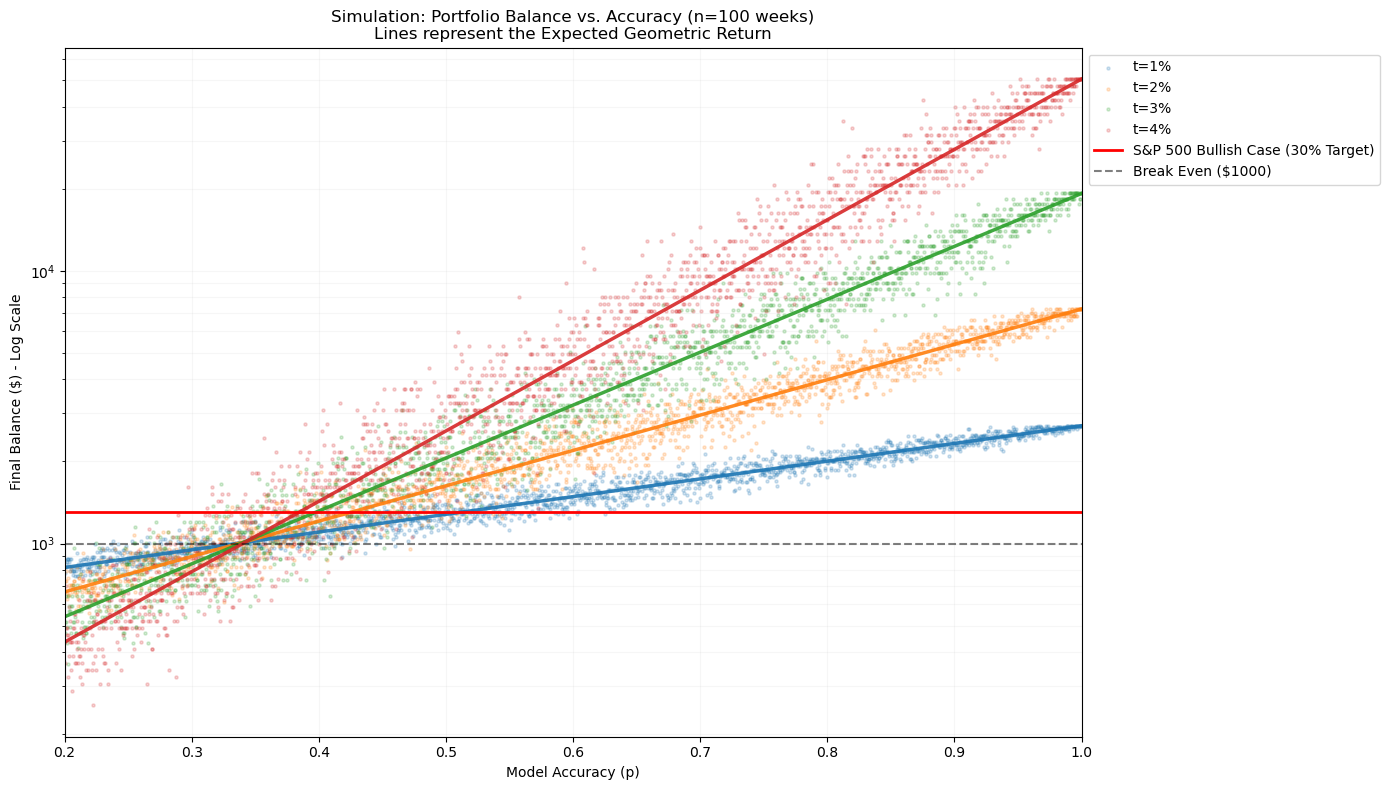

In [21]:
plt.figure(figsize=(14, 8))

for t in targets:
    # 1. Define Multipliers
    r_win = 1 + (t / 100)
    r_loss = 1 - (0.5 * t / 100)

    # 2. Sample Outcomes (The Scatter Points)

    k_samples = np.random.binomial(n, p_axis)
    X_n_samples = X0 * (r_win**k_samples) * (r_loss**(n - k_samples))

    # Plot the scatter and capture the color
    scatter = plt.scatter(p_axis, X_n_samples, alpha=0.2, s=5, label=f't={t}%')
    color = scatter.get_facecolor()[0]

    # 3. Calculate and Plot the Mean Line
    # We use np to represent the expected number of wins.
    # This represents the "center" of the log-normal distribution.
    expected_k = n * p_axis
    mean_line = X0 * (r_win**expected_k) * (r_loss**(n - expected_k))

    plt.plot(p_axis, mean_line, color=color, linewidth=2.5, alpha=0.9)

# Comparing to the S&P500's average two-years return of 30% (bullish case)
plt.axhline(y=X0 * 1.30, color='red', linestyle='-', linewidth=2, label='S&P 500 Bullish Case (30% Target)')
plt.axhline(y=X0, color='black', linestyle='--', alpha=0.5, label='Break Even ($1000)')

# Formatting
plt.yscale('log')
plt.title(f"Simulation: Portfolio Balance vs. Accuracy (n={n} weeks)\nLines represent the Expected Geometric Return")
plt.xlabel("Model Accuracy (p)")
plt.ylabel("Final Balance ($) - Log Scale")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Moved legend outside for clarity
plt.grid(True, which="both", alpha=0.1)
plt.xlim(0.2, 1.0)
plt.tight_layout()
plt.show()

We simulated a compounded weekly investment strategy over a period of 100 trading weeks (n) to observe how different model accuracies (p) yield different balances.
The goal was to help us visualize the balance, following this strategy, as a function of the classification target in % (t) and the accuracy, and to compare it to an initial investment in the S&P500 index (assuming 30% profit).

The parameters:
- n: The duration in weeks of the trading simulation
- X0: Initial balance in $ (1000$ for this run)
- t: Target gains, or the classification target - The model will aim to predict whether a given stock's price will rise t% in the following day
- p: Model accuracy. Here, we simulate the results over different p values

The strategy:
Each week, we feed our model (that has an accuracy of p and classification target t) with different stocks, until we find 1 stock that the model predicts as positive (will rise t% the next day)
We invest all our money in it: We initiate a "stop-loss" command on -0.5t% of our current balance (we risk 0.5t%), and let the stock run.
If the stock falls bellow 0.5t%, we end the trade and wait for next week (with probability 1-p, roughly)
If the stock climbs above t%, we take profit and gain t% (probability t%)

The math:
Our balance after n weeks is a transformation of the Binomial Distribution (parameters n, p). Each point in the plot represents a different run of this strategy (different amount of wins k).
As expected, since n is relatively large, the amount of wins (k) is approximately distributed normally (by the CLT).

Results:
See plot for exact p values for which the simulation beats the S%P500 threshold. These p values are roughly 0.38 < p_threshold < 0.5

Conclusion:
- t values to take into consideration and optimize (hyperparameters) are indeed reasonable daily stocks' gains
- A model accuracy of p > 0.5 could statistically yield impressive gains, comparing to the bullish baseline of the S&P500
